# Qualitative Validation

This notebook visualizes three validation queries using the saved ground truth and `validation_metrics.json`. It does not run model inference.

In [2]:
from pathlib import Path
import json

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

GT_JSON = PROJECT_ROOT / 'data/unified/val_ground_truth.json'
METRICS_JSON = PROJECT_ROOT / 'results/val_fragments/validation_metrics.json'

with open(GT_JSON, 'r', encoding='utf-8') as handle:
    gt = json.load(handle)

with open(METRICS_JSON, 'r', encoding='utf-8') as handle:
    metrics = json.load(handle)

fragments = {fragment['id']: fragment for fragment in gt['fragments']}
queries = {query['query']: query for query in metrics['queries']}

print(metrics['summary'])

{'gt_json': 'data/unified/val_ground_truth.json', 'results_dir': 'results/val_fragments/recto', 'position_tolerance': 50.0, 'num_fragments': 53, 'num_gt_pairs': 36, 'num_directed_gt_pairs': 72, 'num_queries': 51, 'retrieval': {'R@5': 0.18627450980392157, 'R@10': 0.3398692810457516, 'R@15': 0.5620915032679739, 'R@20': 0.7777777777777777, 'R@30': 0.8790849673202613, 'R@40': 0.9313725490196079, 'R@50': 1.0, 'MRR': 0.1460983157374655}, 'positioning': {'R@5': 0.0, 'R@10': 0.0196078431372549, 'R@15': 0.049019607843137254, 'R@20': 0.06862745098039216, 'R@30': 0.10784313725490197, 'R@40': 0.11764705882352941, 'R@50': 0.14705882352941177, 'MRR': 0.018129537142570207, 'NPR': 0.7383346892029912}, 'positioning_given_pair': {'R@5': 0.3888888888888889, 'R@10': 0.5, 'R@15': 0.5555555555555556, 'R@20': 0.6111111111111112, 'R@30': 0.6944444444444444, 'R@40': 0.7222222222222222, 'R@50': 0.75, 'MRR': 0.28150245543384333, 'NPR': 0.7008031073436078}, 'num_warnings': 3}


In [3]:
def load_rgba(fragment_id):
    path = PROJECT_ROOT / fragments[fragment_id]['path']
    image = np.asarray(Image.open(path).convert('RGBA'), dtype=np.float32) / 255.0
    return image


def alpha_blend(dst, src, y0, x0):
    h, w = src.shape[:2]
    region = dst[y0:y0 + h, x0:x0 + w]
    src_alpha = src[..., 3:4]
    dst_alpha = region[..., 3:4]
    out_alpha = src_alpha + dst_alpha * (1.0 - src_alpha)
    out_rgb = np.where(
        out_alpha > 0,
        (src[..., :3] * src_alpha + region[..., :3] * dst_alpha * (1.0 - src_alpha)) / np.maximum(out_alpha, 1e-8),
        0.0,
    )
    region[..., :3] = out_rgb
    region[..., 3:4] = out_alpha
    dst[y0:y0 + h, x0:x0 + w] = region


def compose_query_on_candidate(query_id, candidate_id, query_offset_yx):
    candidate = load_rgba(candidate_id)
    query = load_rgba(query_id)
    dy, dx = np.round(query_offset_yx).astype(int)

    cand_h, cand_w = candidate.shape[:2]
    query_h, query_w = query.shape[:2]
    y_min = min(0, dy)
    x_min = min(0, dx)
    y_max = max(cand_h, dy + query_h)
    x_max = max(cand_w, dx + query_w)

    canvas = np.zeros((y_max - y_min, x_max - x_min, 4), dtype=np.float32)
    cand_y = -y_min
    cand_x = -x_min
    query_y = dy - y_min
    query_x = dx - x_min

    alpha_blend(canvas, candidate, cand_y, cand_x)
    alpha_blend(canvas, query, query_y, query_x)

    boxes = {
        'candidate': (cand_x, cand_y, cand_w, cand_h),
        'query': (query_x, query_y, query_w, query_h),
    }
    return canvas, boxes


def find_given_pair_record(query_record, candidate_id):
    for record in query_record.get('positioning_given_pair', []):
        if record['candidate'] == candidate_id:
            return record
    return None


def plot_panel(ax, query_id, candidate_id, offset_yx, title):
    image, boxes = compose_query_on_candidate(query_id, candidate_id, np.asarray(offset_yx, dtype=float))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(title, fontsize=10)
    cand_x, cand_y, cand_w, cand_h = boxes['candidate']
    query_x, query_y, query_w, query_h = boxes['query']
    ax.add_patch(Rectangle((cand_x, cand_y), cand_w, cand_h, fill=False, edgecolor='tab:blue', linewidth=1.5))
    ax.add_patch(Rectangle((query_x, query_y), query_w, query_h, fill=False, edgecolor='tab:orange', linewidth=1.5))


def rank_text(value):
    return 'NA' if value is None else str(value)


def rank_fraction_text(rank, total):
    if rank is None:
        return f'NA / {total}' if total is not None else 'NA'
    return f'{rank} / {total}' if total is not None else str(rank)

In [4]:
def choose_examples(n=3):
    ordered = sorted(metrics['queries'], key=lambda item: item['query'])
    preferred = [
        item for item in ordered
        if item.get('retrieval', {}).get('first_relevant_rank') is not None
        and item.get('positioning', {}).get('first_hit_rank') is not None
    ]
    fallback = [item for item in ordered if item not in preferred]
    return (preferred + fallback)[:n]


examples = choose_examples(3)
[(item['query'], item['retrieval']['first_relevant_rank'], item['positioning']['first_hit_rank']) for item in examples]

[('PSI D 39-174 recto A+B+C rechts oben det a_1', 11, 196),
 ('PSI D 39-174 recto A+B+C rechts oben det a_2', 8, 57),
 ('PSI D 39-174 recto A+B+C rechts oben det a_3', 12, 19)]

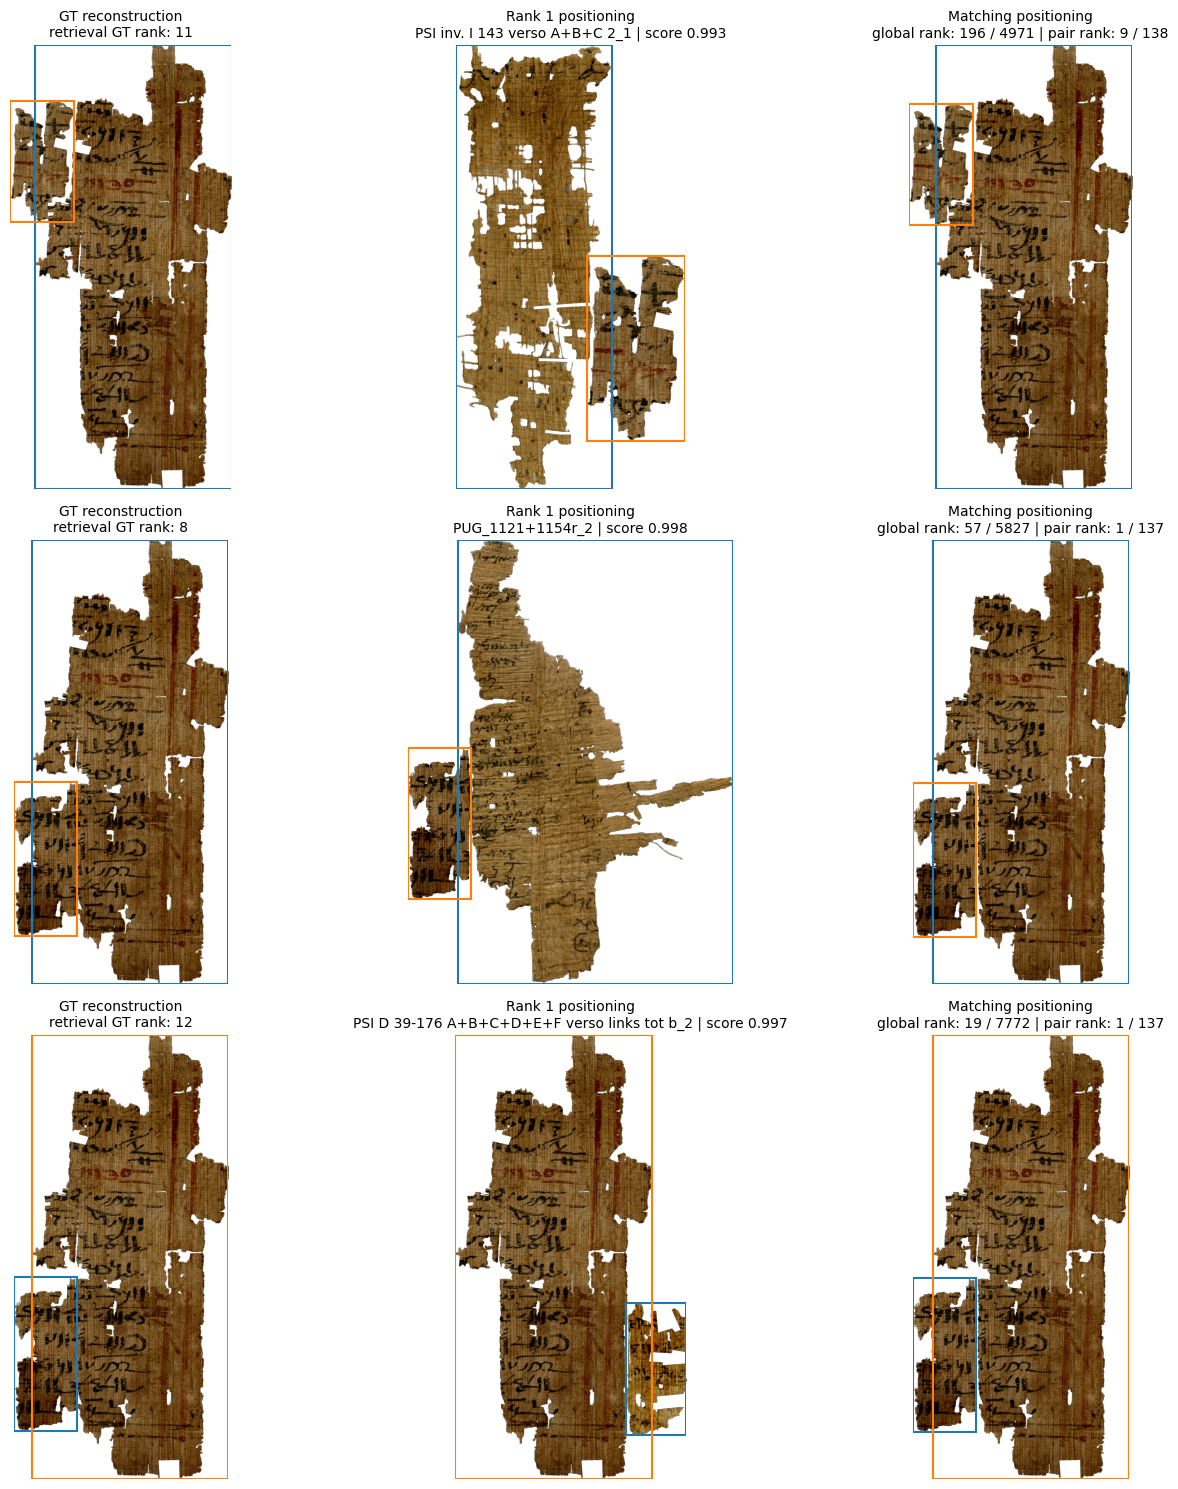

In [5]:
fig, axes = plt.subplots(len(examples), 3, figsize=(15, 5 * len(examples)))
if len(examples) == 1:
    axes = np.asarray([axes])

for row, query_record in enumerate(examples):
    query_id = query_record['query']
    retrieval_rank = query_record['retrieval']['first_relevant_rank']
    rank1 = query_record['positioning'].get('rank_1')
    first_hit = query_record['positioning'].get('first_hit')

    if first_hit is not None:
        gt_candidate_id = first_hit['candidate']
    else:
        gt_candidate_id = query_record['gt_neighbors'][0]

    given_pair = find_given_pair_record(query_record, gt_candidate_id)
    gt_offset = given_pair['gt_offset_yx'] if given_pair is not None else [0, 0]

    plot_panel(
        axes[row, 0],
        query_id=query_id,
        candidate_id=gt_candidate_id,
        offset_yx=gt_offset,
        title=f'GT reconstruction\nretrieval GT rank: {rank_text(retrieval_rank)}',
    )

    if rank1 is not None:
        plot_panel(
            axes[row, 1],
            query_id=query_id,
            candidate_id=rank1['candidate'],
            offset_yx=rank1['offset_yx'],
            title=f"Rank 1 positioning\n{rank1['candidate']} | score {rank1['score']:.3f}",
        )
    else:
        axes[row, 1].axis('off')
        axes[row, 1].set_title('Rank 1 positioning\nmissing')

    if first_hit is not None:
        hit_pair = find_given_pair_record(query_record, first_hit['candidate'])
        pair_rank = hit_pair['first_hit_rank'] if hit_pair is not None else None
        global_total = query_record['positioning'].get('num_position_candidates')
        pair_total = hit_pair.get('num_position_candidates') if hit_pair is not None else None
        plot_panel(
            axes[row, 2],
            query_id=query_id,
            candidate_id=first_hit['candidate'],
            offset_yx=first_hit['offset_yx'],
            title=(
                'Matching positioning\n'
                f"global rank: {rank_fraction_text(first_hit['rank'], global_total)} | "
                f"pair rank: {rank_fraction_text(pair_rank, pair_total)}"
            ),
        )
    else:
        axes[row, 2].axis('off')
        axes[row, 2].set_title('Matching positioning\nnot found')

fig.tight_layout()